In [87]:
# import libraries
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.ticker as ticker
import matplotlib.dates as mdates


In [2]:

# define the constants
C = 1e23
r = 6.3781e6
Q = 1365
sigma = 5.6704e-8
# generate a function for the albedo values
temp = [200,247,282,340]
albedo = [0.7,0.7,0.3,0.3]
alpha = lambda T: np.interp(T,temp,albedo)
# temperature axis
T_eq = np.linspace(0,500,1000)

def plot(epsilon):
    eps = epsilon # choose emissivity
    # Define power in and power out functions

    global P_in
    global P_out

    P_in = np.pi * r**2 * Q * (1 - alpha(T_eq))
    P_out = 4 * np.pi * r**2 * sigma * eps * T_eq**4
    # Plot function
    plt.plot(T_eq, P_in, 'b-.', label=r'$P_{in}$') # plot LHS
    plt.plot(T_eq, P_out, 'r', label=r'$P_{out}$') # plot RHS
    plt.title("Power in vs. Power out for the Energy Balance Model")
    plt.xlabel('Temperature, T(t) (Kelvin)') # x axis label
    plt.ylabel('Power P(T) (W)') # y axis label
    plt.grid() # add grid to plot
    plt.xlim([230,310]) #x axis range
    plt.ylim([5e16,1.4e17]) #y axis range
    plt.legend(loc='upper left') # add legend
    plt.gca().get_yaxis().set_major_formatter(ticker.FormatStrFormatter('%.2e'))
    # Find intersection points
    idx = list(filter(lambda x: ((T_eq[x] < 310) and (T_eq[x] > 230)),
    np.argwhere(np.diff(np.sign(P_in - P_out))).flatten()))
    
    if len(idx) == 0:
        print("No intersection points found!")
    else:
        print("Intersection points:")

    for i in idx:
        print(" T:", round(T_eq[i],2), " T in C:", round(T_eq[i]  - 273.15,2), "P: ", '{:0.2e}'.format(P_in[i]))

    plt.plot(T_eq[idx], P_in[idx], 'ko')
    plt.show()

Intersection points:
 T: 233.73  T in C: -39.42 P:  5.23e+16
 T: 261.26  T in C: -11.89 P:  8.08e+16
 T: 289.29  T in C: 16.14 P:  1.22e+17


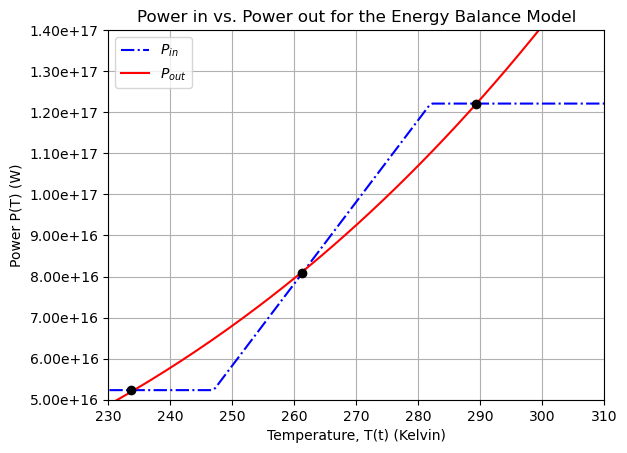

In [3]:
plot(0.6006374223) # plot P_in vs. P_out for given epsilon

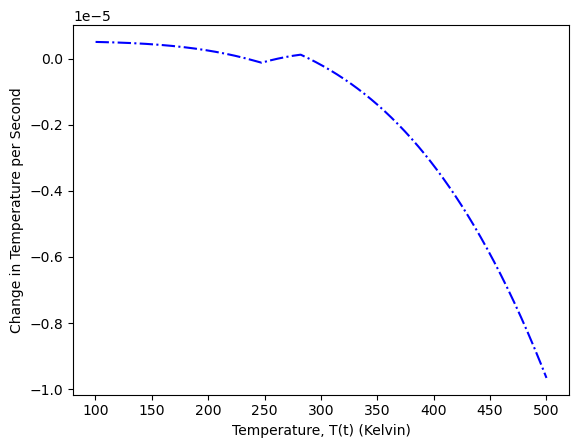

In [23]:
# Noah's own code: 
%matplotlib inline

derivativeT = (P_in - P_out)/C

bottom_cut = 100

cut_temps = T_eq[T_eq > bottom_cut]
cut_derivatives = derivativeT[T_eq > bottom_cut]

plt.title("")
plt.xlabel('Temperature, T(t) (Kelvin)') # x axis label
plt.ylabel('Change in Temperature per Second') # y axis label
plt.plot(cut_temps, cut_derivatives, 'b-.') # plot LHS
plt.show()

In [5]:
# output = dict()

# times = np.linspace(0, 60 * 60 * 24 * 365, 100 )

# output["times"] = times.tolist()
# output["temperatures"] = T_eq[1::20].tolist()

# derivative_temperatures_at_times = []
# for time in times: 
#     derivative_temperatures_at_times.append(derivativeT.tolist()[1::20])
    # for temperature in T_eq: 
    #     derivative_temperatures_at_times[-1].append()


# output["slopes"] = dict()
# for idx, derivative in enumerate(derivativeT[1::20]): 
#     output["slopes"][T_eq[1::20][idx]] = str(derivative)


In [6]:
# import json
# with open("fieldData.json", "w") as f:
#     json.dump(output, f)

In [92]:

# num_elements 

num_times = 30
times = np.linspace(0, 60 * 60 * 24 * 365 - 1, num_times)
derivativeT = (P_in - P_out)/C


top_cut = 310
bottom_cut = 200

cut_temps = T_eq[(T_eq > bottom_cut) & (T_eq < top_cut)]
cut_derivatives = derivativeT[(T_eq > bottom_cut) & (T_eq < top_cut)]

num_temps = 50
idx = np.round(np.linspace(0, len(cut_temps) - 1, num_temps)).astype(int)
temps = cut_temps[idx]

derivatives_reduced = cut_derivatives[idx]

coords_x = np.array([])
coords_y = np.array([])
derivative_at_coordinate = np.array([])

for time in times: 
    coords_x = np.concatenate((coords_x, np.full((len(temps), ), time)))
    coords_y = np.concatenate((coords_y, temps))
    derivative_at_coordinate = np.concatenate((derivative_at_coordinate, derivatives_reduced))


maxDerivative = max(derivative_at_coordinate)
vector_derivative_y = derivative_at_coordinate/maxDerivative
vector_derivative_x =  np.full((len(coords_x), ), 1)
magnitudes = np.sqrt(vector_derivative_y **2 + vector_derivative_x**2)

M = derivative_at_coordinate # np.hypot(vector_derivative_x, vector_derivative_y)

norm_deriv_vector_y = vector_derivative_y / magnitudes
norm_deriv_vector_x = vector_derivative_x / magnitudes

# %matplotlib inline
# fig, ax = plt.subplots()
# q = ax.quiver(coords_x, coords_y, norm_deriv_vector_x, norm_deriv_vector_y, M, headwidth=0, scale=24)

# q = ax.quiver(times, T_eq[1::100],  np.rot90(np.tile((derivativeT[1::100]/derivativeT[1::100]),(10,1)), 3) , np.rot90(np.tile(np.sin(derivativeT[1::100]/maxDerivative),(10,1)), 3))

# ax.quiverkey(q, X=0.3, Y=1.1, U=10,
            #  label='Quiver key, length = 10', labelpos='E')

# ax.scatter(coords_x, coords_y)
# ax.set(xlim=(0, 3e7), ylim=(0, 500))
# plt.show()
# fig.savefig("images/slopeField.svg")
# print(ax)

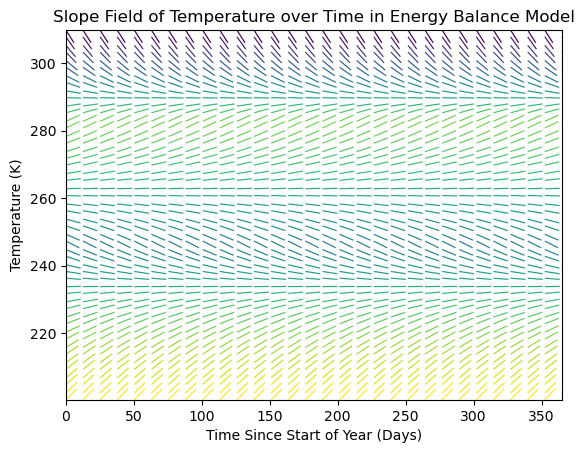

In [109]:
%matplotlib inline
fig, ax = plt.subplots()
x_times =  coords_x / (60 * 60 * 24) # np.datetime64('2025') + coords_x.astype('timedelta64[s]')
# myFmt = mdates.DateFormatter('%j')
# ax.xaxis.set_major_formatter(myFmt)

q = ax.quiver(x_times, coords_y, norm_deriv_vector_x, norm_deriv_vector_y, M, headwidth=0, scale=24)

plt.xlim((min(x_times), 365))
plt.ylim((min(coords_y), max(coords_y)))
plt.title("Slope Field of Temperature over Time in Energy Balance Model")
plt.xlabel("Time Since Start of Year (Days)")
plt.ylabel("Temperature (K)")
plt.show()
fig.savefig("images/slopeField.svg")

In [ ]:
# times = np.datetime64('2025') + coords_x.astype('timedelta64[s]')
# times


array(['2025-01-01T00:00:00', '2025-01-01T00:00:00',
       '2025-01-01T00:00:00', ..., '2026-01-01T00:00:00',
       '2026-01-01T00:00:00', '2026-01-01T00:00:00'],
      dtype='datetime64[s]')

In [9]:
import matplotlib.pyplot as plt
import numpy as np

X = np.arange(-10, 10, 1)
Y = np.arange(-10, 10, 1)
U, V = np.meshgrid(X, Y)

fig, ax = plt.subplots()
q = ax.quiver(X, Y, U, V)
ax.quiverkey(q, X=0.3, Y=1.1, U=10,
             label='Quiver key, length = 10', labelpos='E')

plt.show()


In [10]:
Y

array([-10,  -9,  -8,  -7,  -6,  -5,  -4,  -3,  -2,  -1,   0,   1,   2,
         3,   4,   5,   6,   7,   8,   9])

In [11]:
# Import libraries
import numpy as np
import matplotlib.pyplot as plt


# Creating arrow
x_pos = [1, 1]
y_pos = [2, 0]
x_direct = [1, 0]
y_direct = [1, -1]

# Creating plot
fig, ax = plt.subplots(figsize = (12, 7))
ax.quiver(x_pos, y_pos, x_direct, y_direct,
         scale = 5)

ax.axis([-4, 4, -4, 4])
plt.grid(True)
# show plot
plt.show()